In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.model_selection import TimeSeriesSplit, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [104]:
model_1min = pd.read_csv(
    "steady_state_model_dataset_1min.csv",
    parse_dates=["start_time", "end_time"]
)

In [105]:
features = [
    "power",
    "field_current",
    "inlet_pressure",
    "position"
]

target = "vibration"

In [106]:
model_train = (
    model_1min
    .dropna(subset=features + [target])
    .sort_values("start_time")
    .reset_index(drop=True)
    .copy()
)

X = model_train[features]
y = model_train[target]

In [107]:
ann_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ann", MLPRegressor(
        activation="relu",
        solver="adam",
        max_iter=1000,
        random_state=42,
        early_stopping=False
    ))
])

In [134]:
split_idx = int(len(X) * 0.70)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

In [135]:
param_grid = {
    "ann__hidden_layer_sizes": [
        (16,),
        (32,),
        (32, 16),
        (64, 32),
    ],
    "ann__alpha": [
        0.0001,
        0.001,
        0.01,
    ],
    "ann__learning_rate_init": [
        0.001,
        0.0005,
    ],
}

In [136]:
tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=ann_pipeline,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END ann__alpha=0.0001, ann__hidden_layer_sizes=(32,), ann__learning_rate_init=0.001; total time=   0.5s
[CV] END ann__alpha=0.0001, ann__hidden_layer_sizes=(32,), ann__learning_rate_init=0.0005; total time=   0.5s
[CV] END ann__alpha=0.0001, ann__hidden_layer_sizes=(16,), ann__learning_rate_init=0.001; total time=   0.6s
[CV] END ann__alpha=0.0001, ann__hidden_layer_sizes=(16,), ann__learning_rate_init=0.0005; total time=   0.7s
[CV] END ann__alpha=0.0001, ann__hidden_layer_sizes=(16,), ann__learning_rate_init=0.001; total time=   1.1s
[CV] END ann__alpha=0.0001, ann__hidden_layer_sizes=(32,), ann__learning_rate_init=0.001; total time=   1.3s
[CV] END ann__alpha=0.0001, ann__hidden_layer_sizes=(32,), ann__learning_rate_init=0.0005; total time=   1.1s
[CV] END ann__alpha=0.0001, ann__hidden_layer_sizes=(32,), ann__learning_rate_init=0.001; total time=   1.6s
[CV] END ann__alpha=0.0001, ann__hidden_layer_sizes=(16,), ann_

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'ann__alpha': [0.0001, 0.001, ...], 'ann__hidden_layer_sizes': [(16,), (32,), ...], 'ann__learning_rate_init': [0.001, 0.0005]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,copy,True


In [137]:
best_ann = grid_search.best_estimator_

print("Best parameters:")
print(grid_search.best_params_)

print(f"Best CV RMSE: {-grid_search.best_score_:.4f} mm/s RMS")

Best parameters:
{'ann__alpha': 0.01, 'ann__hidden_layer_sizes': (64, 32), 'ann__learning_rate_init': 0.001}
Best CV RMSE: 0.0405 mm/s RMS


In [138]:
y_pred = best_ann.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Test MAE:  {mae:.4f} mm/s RMS")
print(f"Test RMSE: {rmse:.4f} mm/s RMS")
print(f"Test R²:   {r2:.4f}")

Test MAE:  0.0402 mm/s RMS
Test RMSE: 0.0542 mm/s RMS
Test R²:   0.5540


In [139]:
y_baseline = np.full_like(y_test, y_train.mean(), dtype=float)

baseline_mae = mean_absolute_error(y_test, y_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_baseline))
baseline_r2 = r2_score(y_test, y_baseline)

print(f"Baseline MAE:  {baseline_mae:.4f} mm/s RMS")
print(f"Baseline RMSE: {baseline_rmse:.4f} mm/s RMS")
print(f"Baseline R²:   {baseline_r2:.4f}")

Baseline MAE:  0.0665 mm/s RMS
Baseline RMSE: 0.0911 mm/s RMS
Baseline R²:   -0.2584


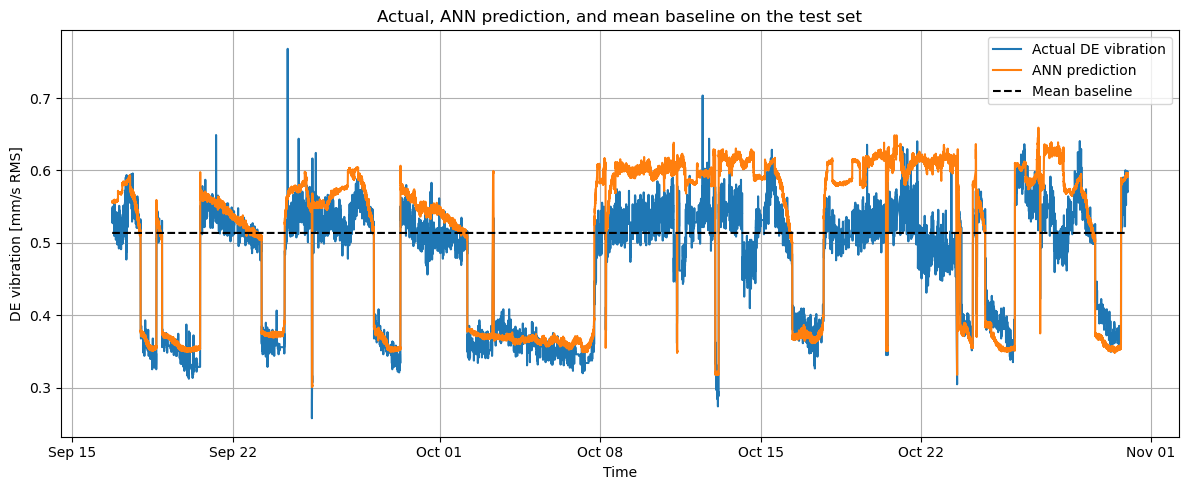

In [140]:
results_ann = pd.DataFrame({
    "start_time": model_train.loc[X_test.index, "start_time"].values,
    "actual": y_test.values,
    "predicted": y_pred,
    "baseline": y_baseline,
})

plt.figure(figsize=(12, 5))

plt.plot(results_ann["start_time"], results_ann["actual"], label="Actual DE vibration")
plt.plot(results_ann["start_time"], results_ann["predicted"], label="ANN prediction")
plt.plot(results_ann["start_time"], results_ann["baseline"], linestyle="--", color="black", label="Mean baseline")

plt.xlabel("Time")
plt.ylabel("DE vibration [mm/s RMS]")
plt.title("Actual, ANN prediction, and mean baseline on the test set")
plt.legend()
plt.grid(True)
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.tight_layout()

plt.savefig("actual_predicted_baseline_test.png", dpi=300, bbox_inches="tight")

plt.show()

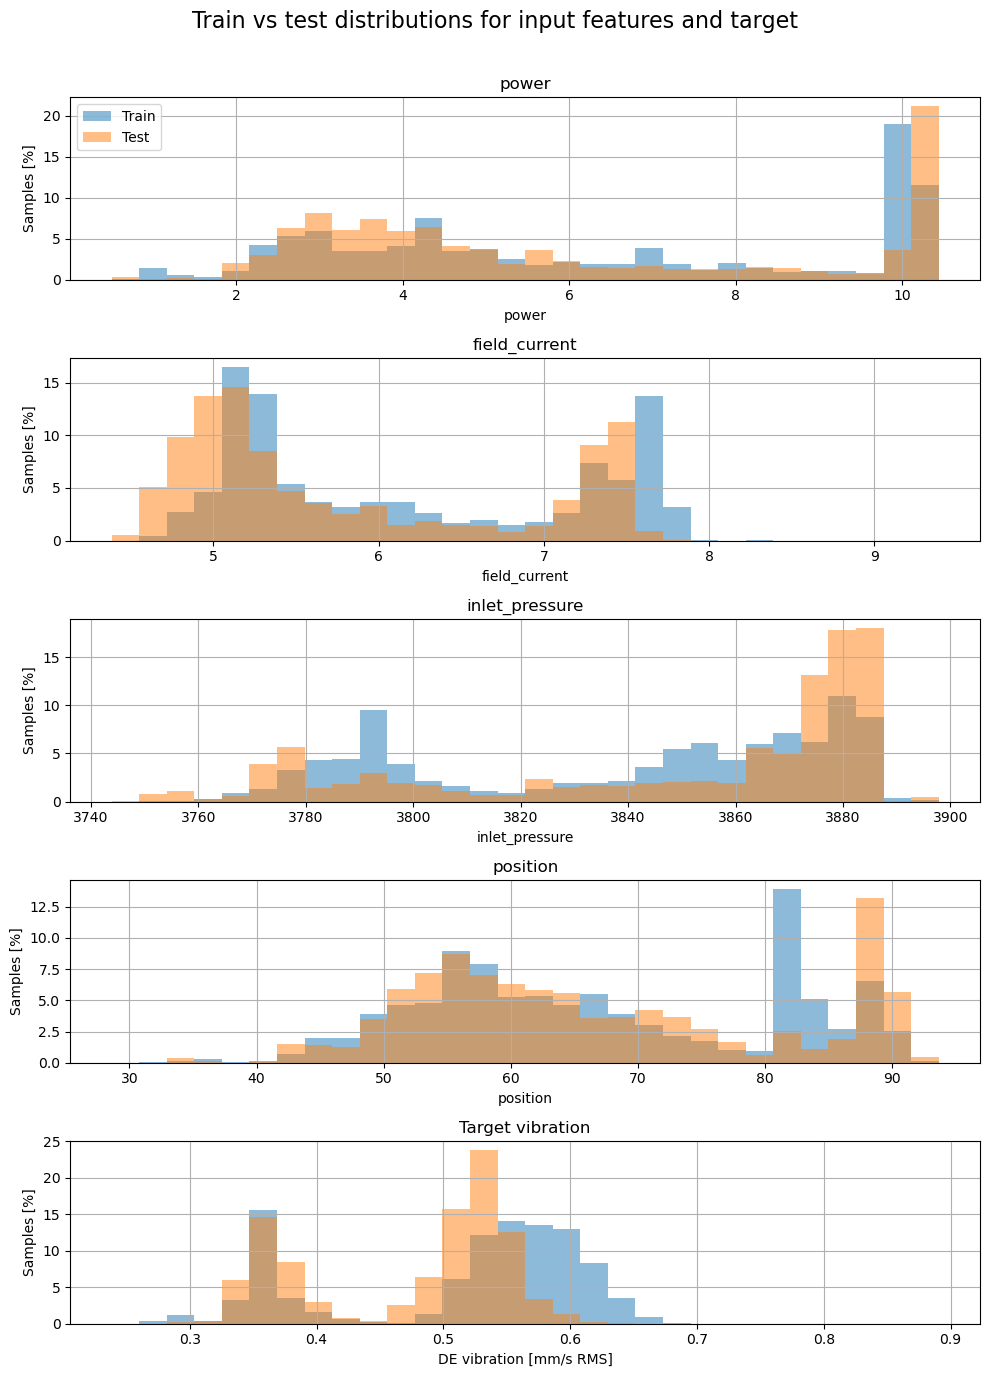

In [155]:
import numpy as np
import matplotlib.pyplot as plt

columns_to_plot = features + [target]

fig, axes = plt.subplots(len(columns_to_plot), 1, figsize=(10, 14), sharey=False)

for i, col in enumerate(columns_to_plot):
    ax = axes[i]

    if col == target:
        train_values = np.asarray(y_train)
        test_values = np.asarray(y_test)
        xlabel = "DE vibration [mm/s RMS]"
        title = "Target vibration"
    else:
        train_values = X_train[col].to_numpy()
        test_values = X_test[col].to_numpy()
        xlabel = col
        title = col

    train_values = train_values[~np.isnan(train_values)]
    test_values = test_values[~np.isnan(test_values)]

    combined_values = np.concatenate([train_values, test_values])
    bins = np.linspace(combined_values.min(), combined_values.max(), 31)

    train_weights = np.ones(len(train_values)) / len(train_values) * 100
    test_weights = np.ones(len(test_values)) / len(test_values) * 100

    ax.hist(train_values, bins=bins, alpha=0.5, weights=train_weights, label="Train")
    ax.hist(test_values, bins=bins, alpha=0.5, weights=test_weights, label="Test")

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Samples [%]")
    ax.set_title(title)
    ax.grid(True)

    if i == 0:
        ax.legend()

fig.suptitle("Train vs test distributions for input features and target", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("train_test_feature_target_histograms_vertical.png", dpi=300, bbox_inches="tight")
plt.show()

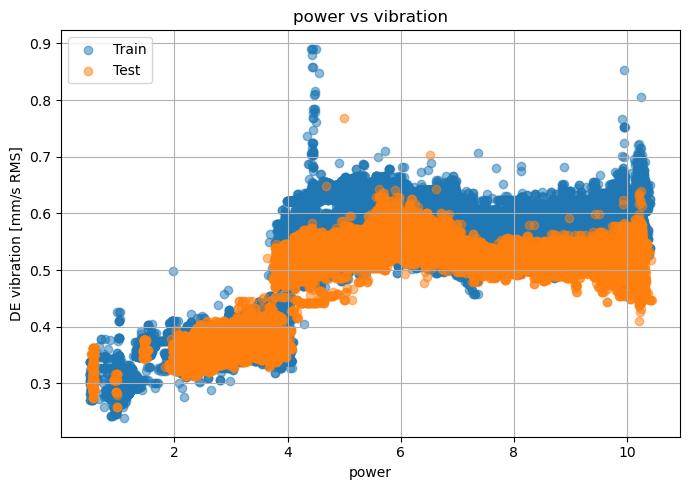

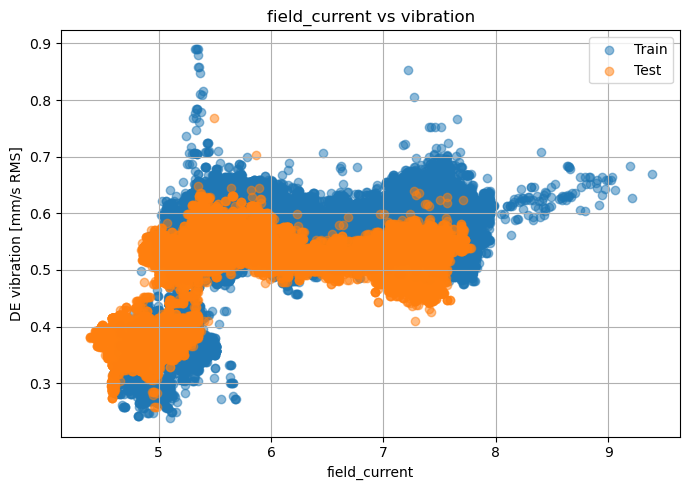

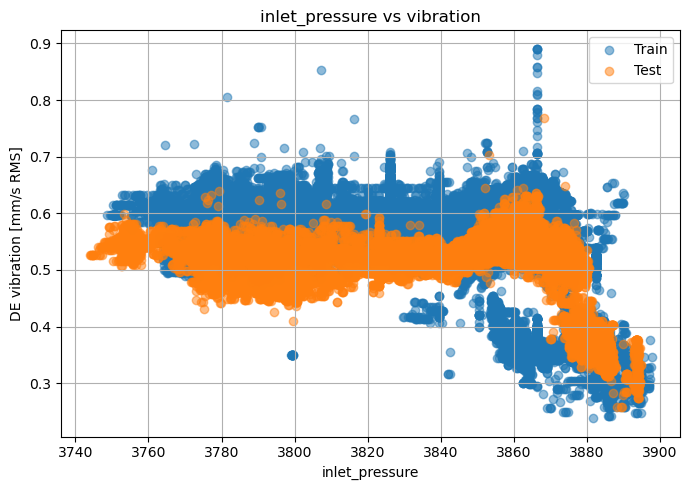

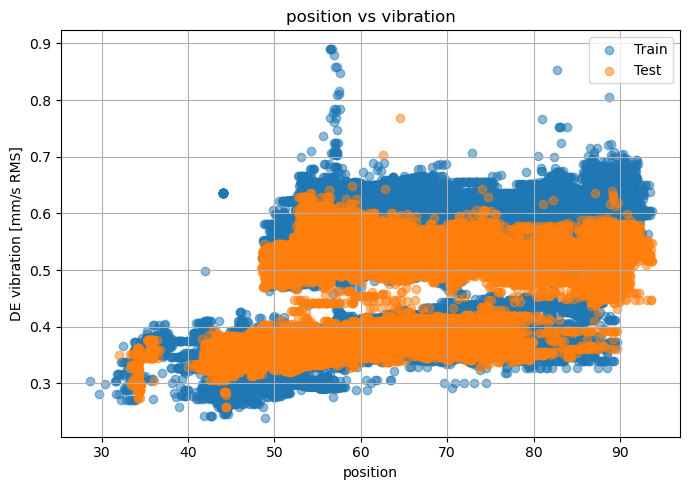

In [143]:
for feature in features:
    plt.figure(figsize=(7, 5))

    plt.scatter(
        X_train[feature],
        y_train,
        alpha=0.5,
        label="Train"
    )

    plt.scatter(
        X_test[feature],
        y_test,
        alpha=0.5,
        label="Test"
    )

    plt.xlabel(feature)
    plt.ylabel("DE vibration [mm/s RMS]")
    plt.title(f"{feature} vs vibration")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(f"{feature}_vs_vibration_train_test.png", dpi=300, bbox_inches="tight")
    plt.show()

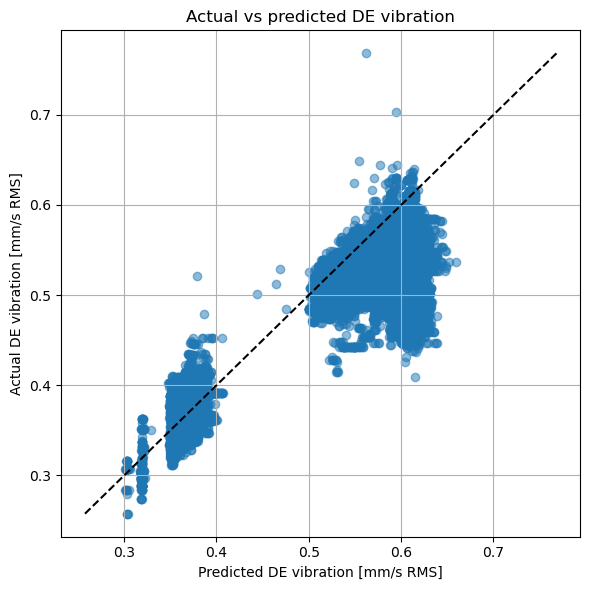

In [90]:
plt.figure(figsize=(6, 6))
plt.scatter(results_ann["predicted"], results_ann["actual"], alpha=0.5)

min_val = min(results_ann["actual"].min(), results_ann["predicted"].min())
max_val = max(results_ann["actual"].max(), results_ann["predicted"].max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    color="black"
)

plt.xlabel("Predicted DE vibration [mm/s RMS]")
plt.ylabel("Actual DE vibration [mm/s RMS]")
plt.title("Actual vs predicted DE vibration")
plt.grid(True)
plt.tight_layout()

plt.savefig("actual_vs_predicted_scatter.png", dpi=300, bbox_inches="tight")

plt.show()

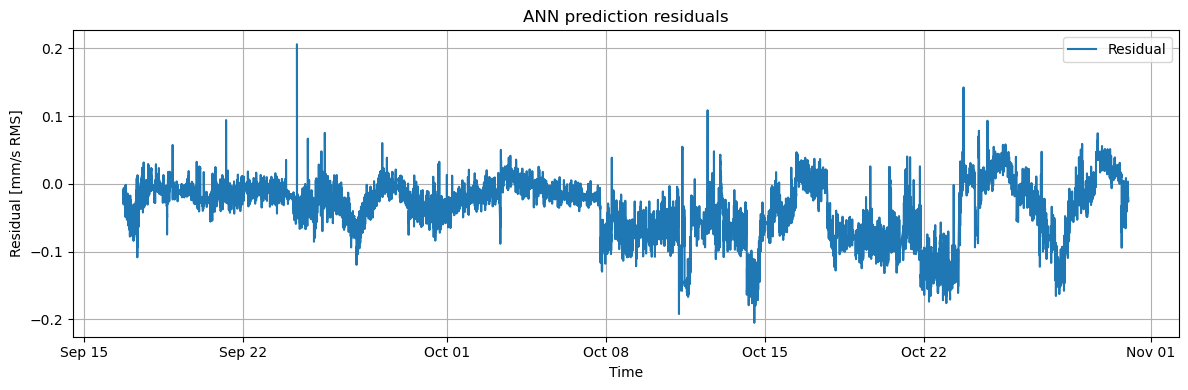

In [153]:
results_ann["residual"] = results_ann["actual"] - results_ann["predicted"]

plt.figure(figsize=(12, 4))

plt.plot(results_ann["start_time"], results_ann["residual"], label="Residual")

plt.xlabel("Time")
plt.ylabel("Residual [mm/s RMS]")
plt.title("ANN prediction residuals")
plt.grid(True)
plt.legend()
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.tight_layout()

plt.savefig("ann_residuals_test.png", dpi=300, bbox_inches="tight")

plt.show()

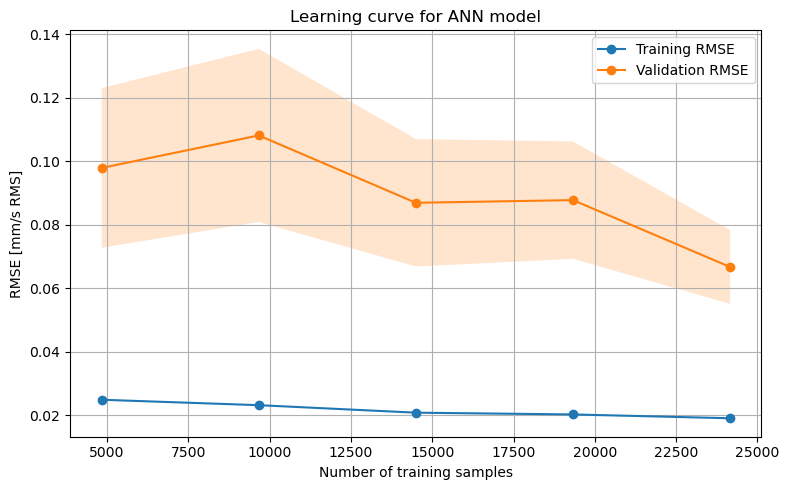

In [98]:
from sklearn.model_selection import learning_curve, TimeSeriesSplit
import matplotlib.pyplot as plt

tscv = TimeSeriesSplit(n_splits=5)

train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_ann,
    X=X_train,
    y=y_train,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.2, 1.0, 5),
    n_jobs=-1
)

train_rmse = -train_scores
val_rmse = -val_scores

train_mean = train_rmse.mean(axis=1)
train_std = train_rmse.std(axis=1)

val_mean = val_rmse.mean(axis=1)
val_std = val_rmse.std(axis=1)

plt.figure(figsize=(8, 5))

plt.plot(train_sizes, train_mean, marker="o", label="Training RMSE")
plt.plot(train_sizes, val_mean, marker="o", label="Validation RMSE")

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

plt.xlabel("Number of training samples")
plt.ylabel("RMSE [mm/s RMS]")
plt.title("Learning curve for ANN model")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

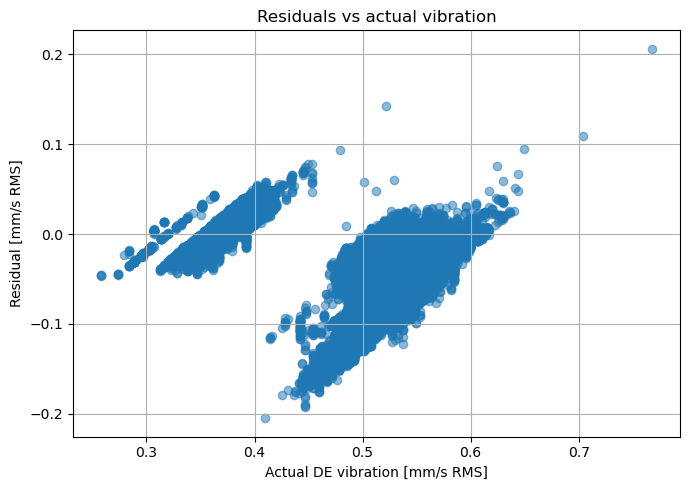

In [154]:
residuals = y_test - y_pred

plt.figure(figsize=(7, 5))
plt.scatter(y_test, residuals, alpha=0.5)

plt.xlabel("Actual DE vibration [mm/s RMS]")
plt.ylabel("Residual [mm/s RMS]")
plt.title("Residuals vs actual vibration")
plt.grid(True)

plt.tight_layout()
plt.savefig("residuals_vs_actual_vibration.png", dpi=300, bbox_inches="tight")
plt.show()

In [147]:
error_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted": np.ravel(y_pred),
})

error_df["residual"] = error_df["actual"] - error_df["predicted"]
error_df["absolute_error"] = error_df["residual"].abs()
error_df["squared_error"] = error_df["residual"] ** 2

error_df["vibration_bin"] = pd.cut(
    error_df["actual"],
    bins=[0.25, 0.35, 0.45, 0.55, 0.65, 0.80]
)

bin_errors = error_df.groupby("vibration_bin", observed=False).agg(
    n_samples=("absolute_error", "count"),
    mean_actual=("actual", "mean"),
    mean_prediction=("predicted", "mean"),
    mean_residual=("residual", "mean"),
    mae=("absolute_error", "mean"),
    rmse=("squared_error", lambda x: np.sqrt(np.mean(x)))
)

bin_errors["percentage_of_test"] = (
    bin_errors["n_samples"] / len(error_df) * 100
)

print(bin_errors)

               n_samples  mean_actual  mean_prediction  mean_residual  \
vibration_bin                                                           
(0.25, 0.35]        5277     0.338306         0.356505      -0.018199   
(0.35, 0.45]       15704     0.373392         0.369580       0.003812   
(0.45, 0.55]       34021     0.519133         0.576587      -0.057455   
(0.55, 0.65]        7116     0.567095         0.593783      -0.026688   
(0.65, 0.8]            2     0.735904         0.578455       0.157449   

                    mae      rmse  percentage_of_test  
vibration_bin                                          
(0.25, 0.35]   0.018373  0.019653            8.494849  
(0.35, 0.45]   0.014403  0.021336           25.280103  
(0.45, 0.55]   0.058001  0.069680           54.766581  
(0.55, 0.65]   0.028439  0.033983           11.455248  
(0.65, 0.8]    0.157449  0.164821            0.003220  
